# Khám phá dữ liệu trên raw dataset

## Train data

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# 1. Tải dữ liệu
path = r'D:\Projects\Assignment\LLM & AI Assistant Projects\Hate Speech Detection\data\raw\train_nor_811.xlsx'
df = pd.read_excel(path)

# 2. Kiểm tra tổng quan
print("--- Thông tin tổng quan ---")
print(df.info())
print("\n--- 5 dòng đầu tiên ---")
print(df.head())
print("\n--- shape của dữ liệu ---")
print(df.shape)

--- Thông tin tổng quan ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5548 entries, 0 to 5547
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5548 non-null   int64 
 1   Emotion     5548 non-null   object
 2   Sentence    5548 non-null   object
dtypes: int64(1), object(2)
memory usage: 130.2+ KB
None

--- 5 dòng đầu tiên ---
   Unnamed: 0    Emotion                                           Sentence
0         188      Other              cho mình xin bài nhạc tên là gì với ạ
1         166    Disgust  cho đáng đời con quỷ . về nhà lôi con nhà mày ...
2        1345    Disgust  lo học đi . yêu đương lol gì hay lại thích học...
3         316  Enjoyment    uớc gì sau này về già vẫn có thể như cụ này :))
4        1225  Enjoyment  mỗi lần có video của con là cứ coi đi coi lại ...

--- shape của dữ liệu ---
(5548, 3)



--- Dữ liệu thiếu ---
Unnamed: 0    0
Emotion       0
Sentence      0
dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_19324\531086257.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Emotion', order=df['Emotion'].value_counts().index, palette='viridis')


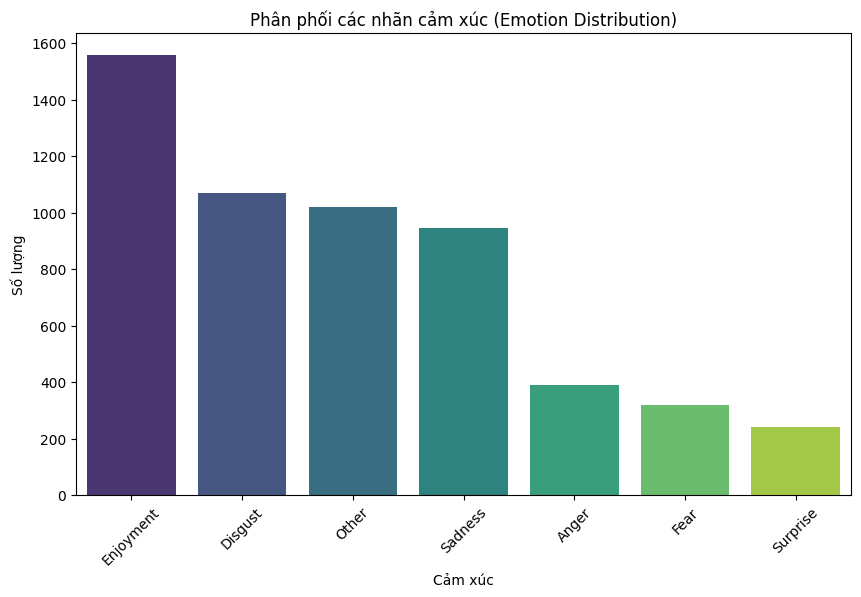

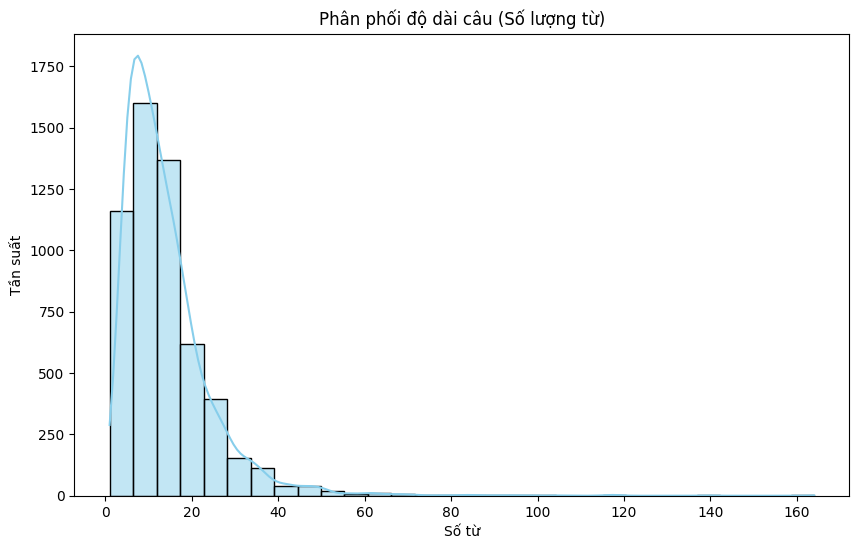


--- Top 20 từ xuất hiện nhiều nhất ---
không: 1130
tao: 1052
là: 1006
có: 1003
mà: 847
này: 727
nó: 717
đi: 683
thì: 666
người: 662
con: 643
rồi: 611
cái: 573
cho: 552
per: 537
được: 522
cũng: 486
gì: 472
như: 472
làm: 446

--- Ví dụ tiêu biểu cho mỗi cảm xúc ---
[Other]: cho mình xin bài nhạc tên là gì với ạ...
[Disgust]: cho đáng đời con quỷ . về nhà lôi con nhà mày ra mà đánh 😡...
[Enjoyment]: uớc gì sau này về già vẫn có thể như cụ này :))...
[Anger]: thằng kia sao mày bắt vợ với bồ tao dọn thế kia . nhà mày ở đâu tao đến thịt mày chết...
[Surprise]: thật hay đùa ác vậy . không thể tin được...
[Sadness]: per nghe đi rồi khóc 1 trận cho thoải mái . đừng cố gồng mình lên nữa...
[Fear]: thời buổi bây chừ chuyện gì cũng có thể xảy ra , vậy nên thôi trất , đừng nên tin ai...


In [5]:
# 3. Kiểm tra dữ liệu thiếu (Missing values)
print("\n--- Dữ liệu thiếu ---")
print(df.isnull().sum())

# 4. Phân tích phân phối các nhãn cảm xúc (Emotion)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Emotion', order=df['Emotion'].value_counts().index, palette='viridis')
plt.title('Phân phối các nhãn cảm xúc (Emotion Distribution)')
plt.xlabel('Cảm xúc')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)
plt.show()

# 5. Phân tích độ dài văn bản
# Tính số từ trong mỗi câu
df['Word_Count'] = df['Sentence'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['Word_Count'], bins=30, kde=True, color='skyblue')
plt.title('Phân phối độ dài câu (Số lượng từ)')
plt.xlabel('Số từ')
plt.ylabel('Tần suất')
plt.show()

# 6. Thống kê từ vựng phổ biến nhất (Top Keywords)
def get_top_words(column, top_n=20):
    words = []
    for text in column:
        # Làm sạch cơ bản: chuyển chữ thường, bỏ ký tự đặc biệt
        clean_text = re.sub(r'[^\w\s]', '', str(text).lower())
        words.extend(clean_text.split())
    return Counter(words).most_common(top_n)

top_words = get_top_words(df['Sentence'])
print("\n--- Top 20 từ xuất hiện nhiều nhất ---")
for word, count in top_words:
    print(f"{word}: {count}")

# 7. Xem xét ví dụ cụ thể cho mỗi loại cảm xúc
print("\n--- Ví dụ tiêu biểu cho mỗi cảm xúc ---")
emotions = df['Emotion'].unique()
for emo in emotions:
    sample = df[df['Emotion'] == emo]['Sentence'].iloc[0]
    print(f"[{emo}]: {sample[:100]}...")

In [9]:
# 1. Tải dữ liệu
path = r'D:\Projects\Assignment\LLM & AI Assistant Projects\Hate Speech Detection\data\raw\test_nor_811.xlsx'
df = pd.read_excel(path)

# 2. Kiểm tra tổng quan
print("--- Thông tin tổng quan ---")
print(df.info())
print("\n--- 5 dòng đầu tiên ---")
print(df.head())
print("\n--- shape của dữ liệu ---")
print(df.shape)

--- Thông tin tổng quan ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693 entries, 0 to 692
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  693 non-null    int64 
 1   Emotion     693 non-null    object
 2   Sentence    693 non-null    object
dtypes: int64(1), object(2)
memory usage: 16.4+ KB
None

--- 5 dòng đầu tiên ---
   Unnamed: 0   Emotion                                           Sentence
0         713   Sadness                   người ta có bạn bè nhìn vui thật
1        1827  Surprise          cho nghỉ viêc mói đúng sao goi là kỷ luật
2        1166   Disgust                                         kinh vãi 😡
3         228      Fear  nhà thì không xa lắm nhưng chưa bao giờ đi vì ...
4        1942     Anger      bố không thích nộp đấy mày thích ý kiến không

--- shape của dữ liệu ---
(693, 3)



--- Dữ liệu thiếu ---
Unnamed: 0    0
Emotion       0
Sentence      0
dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_19324\531086257.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Emotion', order=df['Emotion'].value_counts().index, palette='viridis')


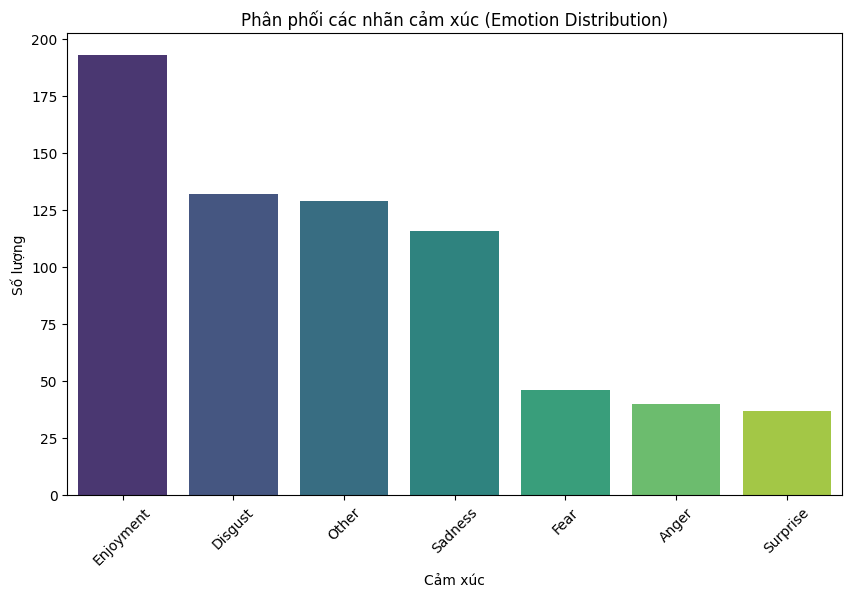

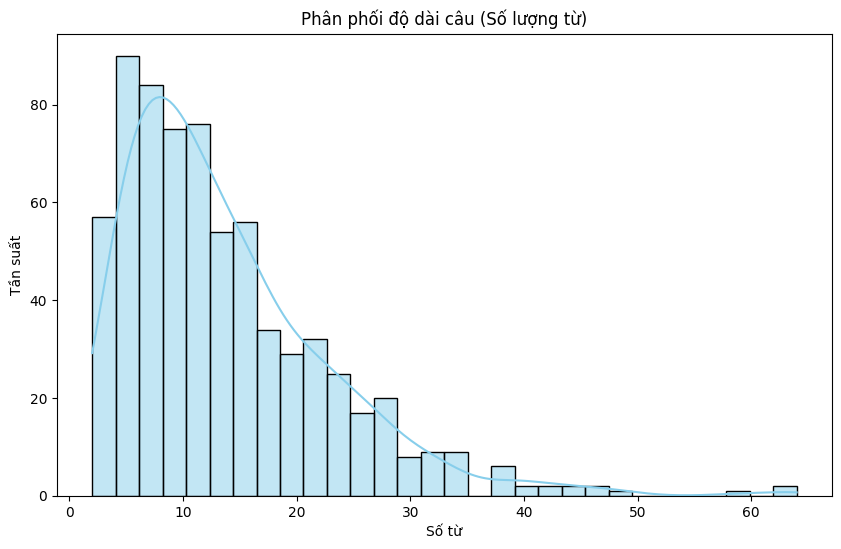


--- Top 20 từ xuất hiện nhiều nhất ---
là: 133
tao: 129
không: 123
có: 99
mà: 98
đi: 84
rồi: 75
nó: 75
được: 72
người: 70
thì: 70
cũng: 69
này: 68
như: 66
cái: 66
cho: 63
per: 62
còn: 62
con: 61
gì: 60

--- Ví dụ tiêu biểu cho mỗi cảm xúc ---
[Sadness]: người ta có bạn bè nhìn vui thật...
[Surprise]: cho nghỉ viêc mói đúng sao goi là kỷ luật...
[Disgust]: kinh vãi 😡...
[Fear]: nhà thì không xa lắm nhưng chưa bao giờ đi vì sợ bị đè bẹp luôn người =)))))...
[Anger]: bố không thích nộp đấy mày thích ý kiến không...
[Other]: bắt cóc bỏ đĩa . quanh đi quẩn lại chỉ khổ dân đen thôi !...
[Enjoyment]: một hành động đẹp đầy tính nhân văn ☺️☺️...


In [7]:
# 3. Kiểm tra dữ liệu thiếu (Missing values)
print("\n--- Dữ liệu thiếu ---")
print(df.isnull().sum())

# 4. Phân tích phân phối các nhãn cảm xúc (Emotion)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Emotion', order=df['Emotion'].value_counts().index, palette='viridis')
plt.title('Phân phối các nhãn cảm xúc (Emotion Distribution)')
plt.xlabel('Cảm xúc')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)
plt.show()

# 5. Phân tích độ dài văn bản
# Tính số từ trong mỗi câu
df['Word_Count'] = df['Sentence'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['Word_Count'], bins=30, kde=True, color='skyblue')
plt.title('Phân phối độ dài câu (Số lượng từ)')
plt.xlabel('Số từ')
plt.ylabel('Tần suất')
plt.show()

# 6. Thống kê từ vựng phổ biến nhất (Top Keywords)
def get_top_words(column, top_n=20):
    words = []
    for text in column:
        # Làm sạch cơ bản: chuyển chữ thường, bỏ ký tự đặc biệt
        clean_text = re.sub(r'[^\w\s]', '', str(text).lower())
        words.extend(clean_text.split())
    return Counter(words).most_common(top_n)

top_words = get_top_words(df['Sentence'])
print("\n--- Top 20 từ xuất hiện nhiều nhất ---")
for word, count in top_words:
    print(f"{word}: {count}")

# 7. Xem xét ví dụ cụ thể cho mỗi loại cảm xúc
print("\n--- Ví dụ tiêu biểu cho mỗi cảm xúc ---")
emotions = df['Emotion'].unique()
for emo in emotions:
    sample = df[df['Emotion'] == emo]['Sentence'].iloc[0]
    print(f"[{emo}]: {sample[:100]}...")